In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_excel(r"C:\Users\meetv\OneDrive\Desktop\jupyter notebook\daily-minimum-temperatures-in-me.xlsx")
df['Date'] = pd.to_datetime(df['Date'])

print(df.info())
print(df.head())


df['Daily_min_temp'] = pd.to_numeric(df['Daily_min_temp'], errors='coerce')

df = df.dropna(subset=['Daily_min_temp'])

summary_stats = df['Daily_min_temp'].agg(['mean', 'median', 'std'])
print(summary_stats)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            3650 non-null   datetime64[ns]
 1   Daily_min_temp  3650 non-null   object        
dtypes: datetime64[ns](1), object(1)
memory usage: 57.2+ KB
None
        Date Daily_min_temp
0 1981-01-01           20.7
1 1981-01-02           17.9
2 1981-01-03           18.8
3 1981-01-04           14.6
4 1981-01-05           15.8
mean      11.186647
median    11.000000
std        4.061671
Name: Daily_min_temp, dtype: float64


In [18]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_week'] = df['Date'].dt.dayofweek
df['Week_of_year'] = df['Date'].dt.isocalendar().week



In [19]:
df['Daily_min_temp'] = df['Daily_min_temp'].astype(str)
df['Daily_min_temp'] = df['Daily_min_temp'].str.replace('?', '', regex=False)
df['Daily_min_temp'] = pd.to_numeric(df['Daily_min_temp'], errors='coerce')
print(df)

df.to_excel("cleaned_temparature.xlsx" , index=False)


           Date  Daily_min_temp  Year  Month  Day  Day_of_week  Week_of_year
0    1981-01-01            20.7  1981      1    1            3             1
1    1981-01-02            17.9  1981      1    2            4             1
2    1981-01-03            18.8  1981      1    3            5             1
3    1981-01-04            14.6  1981      1    4            6             1
4    1981-01-05            15.8  1981      1    5            0             2
...         ...             ...   ...    ...  ...          ...           ...
3645 1990-12-27            14.0  1990     12   27            3            52
3646 1990-12-28            13.6  1990     12   28            4            52
3647 1990-12-29            13.5  1990     12   29            5            52
3648 1990-12-30            15.7  1990     12   30            6            52
3649 1990-12-31            13.0  1990     12   31            0             1

[3647 rows x 7 columns]


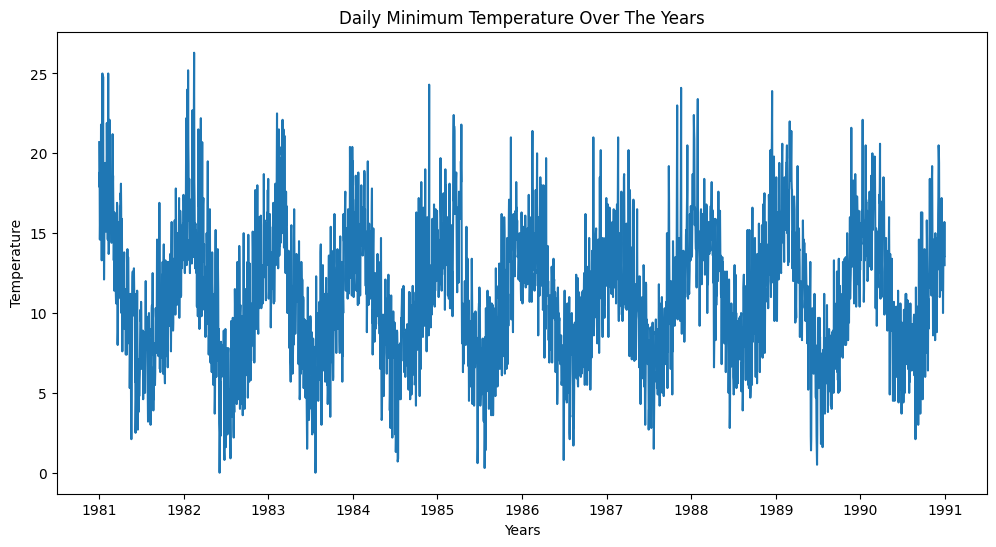

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Daily_min_temp'])
plt.title("Daily Minimum Temperature Over The Years")
plt.xlabel("Years")
plt.ylabel("Temperature")
plt.show()


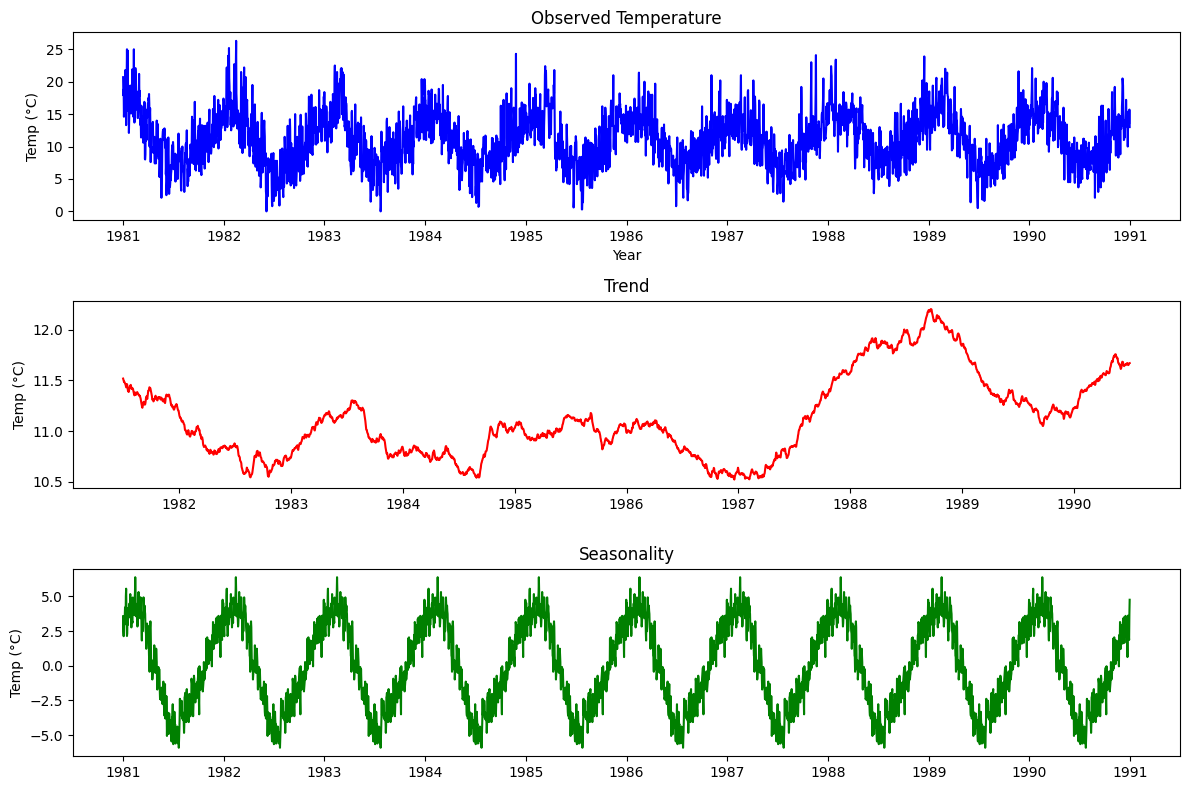

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

df = df.dropna(subset=['Daily_min_temp'])

df['Date'] = pd.to_datetime(df['Date'])

result = seasonal_decompose(df['Daily_min_temp'], model='additive', period=365)

plt.figure(figsize=(12,8))

plt.subplot(3,1,1)
plt.plot(df['Date'], df['Daily_min_temp'], color='blue') 
plt.xlabel('Year')
plt.ylabel('Temp (°C)')
plt.title('Observed Temperature')

plt.subplot(3,1,2)
plt.plot(df['Date'], result.trend, color='red')
plt.title('Trend')
plt.ylabel('Temp (°C)')

plt.subplot(3,1,3)
plt.plot(df['Date'], result.seasonal, color='green')
plt.title('Seasonality')
plt.ylabel('Temp (°C)')

plt.tight_layout()
plt.show()


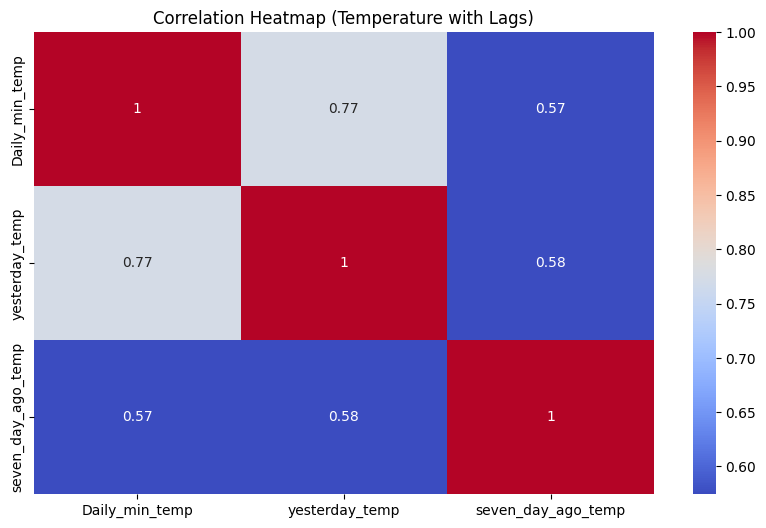

In [22]:
import seaborn as sns

df['yesterday_temp'] = df['Daily_min_temp']. shift(1)

df['seven_day_ago_temp'] = df['Daily_min_temp']. shift(7)

corr  = df[['Daily_min_temp','yesterday_temp','seven_day_ago_temp']].corr()

plt.figure(figsize=(10,6))

sns. heatmap(corr, annot=True, cmap="coolwarm")

plt. title("Correlation Heatmap (Temperature with Lags)")

plt.show()



In [41]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


print(df.head())

print("\nMissing values before handling:\n", df.isnull().sum())

df['Daily_min_temp'].fillna(method='ffill', inplace=True)

df['Daily_min_temp'].interpolate(method='linear', inplace=True)

print("\nMissing values after handling:\n", df.isnull().sum())

         Date  Daily_min_temp  Year     Month  Day  Day_of_week  Week_of_year  \
12 1981-01-13        1.365926  1981 -1.608624   13            1             3   
13 1981-01-14        2.551174  1981 -1.608624   14            2             3   
14 1981-01-15        3.415418  1981 -1.608624   15            3             3   
15 1981-01-16        2.353633  1981 -1.608624   16            4             3   
16 1981-01-17        2.328940  1981 -1.608624   17            5             3   

    yesterday_temp  seven_day_ago_temp  DayOfWeek  ...   Fall  Spring  Summer  \
12        0.525570                15.8  -1.000000  ...  False   False   False   
13        1.364597                15.8  -0.500137  ...  False   False   False   
14        2.549105                17.4  -0.000275  ...  False   False   False   
15        3.412809                21.8   0.499588  ...  False   False   False   
16        2.351687                20.0   0.999450  ...  False   False   False   

    Winter   Fall  Spring 

C:\Users\meetv\AppData\Local\Temp\ipykernel_17216\2924146381.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Daily_min_temp'].fillna(method='ffill', inplace=True)
C:\Users\meetv\AppData\Local\Temp\ipykernel_17216\2924146381.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Daily_min_temp'].fillna(method='ffill', inplace=True)
C:\Users\meetv\AppData\Local\Temp\ipykernel_17216\2924146381.py:14: FutureWarning: A value is tryin

In [27]:
df['Date'] = pd.to_datetime(df['Date'])

df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

df['Lag_1'] = df['Daily_min_temp'].shift(1)

df = df.dropna()

Season_dummies = pd.get_dummies(df['Season'])
df = pd.concat([df, Season_dummies], axis=1)
df.drop('Season', axis=1, inplace=True)

print(Season_dummies)


       Fall  Spring  Summer  Winter
8     False   False   False    True
9     False   False   False    True
10    False   False   False    True
11    False   False   False    True
12    False   False   False    True
...     ...     ...     ...     ...
3645  False   False   False    True
3646  False   False   False    True
3647  False   False   False    True
3648  False   False   False    True
3649  False   False   False    True

[3639 rows x 4 columns]


In [28]:
Q1 = df['Date'].quantile(0.25)
Q3 = df['Date'].quantile(0.75)

IQR = Q3 - Q1

outliers_iqr = df[(df['Date'] < Q1 - 1.5*IQR) | (df['Date'] > Q3 + 1.5*IQR)]

z_scores = np.abs(stats.zscore(df['Date']))
outliers_z = df[z_scores > 3]

print(f"\nNumber of IQR outliers: {len(outliers_iqr)}")
print(f"Number of Z-score outliers: {len(outliers_z)}")



Number of IQR outliers: 0
Number of Z-score outliers: 0


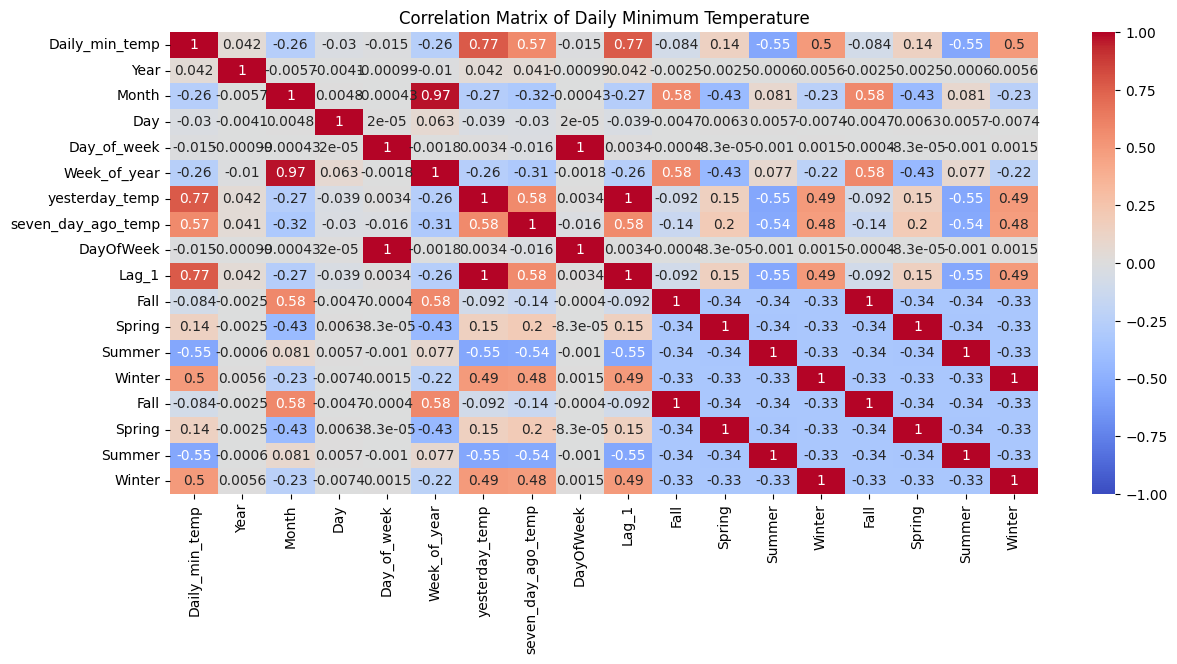

In [30]:
df['Daily_min_temp'] = (df['Daily_min_temp'].astype(str).str.replace('?', '', regex=False).astype(float))

plt.figure(figsize=(14,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Daily Minimum Temperature')
plt.show()


In [33]:
df['yesterday_temp'] = df['Daily_min_temp'].shift(1)

df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

df = df.dropna()

numeric_cols = ['Daily_min_temp', 'yesterday_temp', 'DayOfWeek', 'Month']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())


         Date  Daily_min_temp  Year     Month  Day  Day_of_week  Week_of_year  \
10 1981-01-11        1.242462  1981 -1.608624   11            6             2   
11 1981-01-12        0.526374  1981 -1.608624   12            0             3   
12 1981-01-13        1.365926  1981 -1.608624   13            1             3   
13 1981-01-14        2.551174  1981 -1.608624   14            2             3   
14 1981-01-15        3.415418  1981 -1.608624   15            3             3   

    yesterday_temp  seven_day_ago_temp  DayOfWeek  Lag_1   Fall  Spring  \
10        2.178946                14.6   1.499313   20.0  False   False   
11        1.241211                15.8  -1.499863   16.2  False   False   
12        0.525570                15.8  -1.000000   13.3  False   False   
13        1.364597                15.8  -0.500137   16.7  False   False   
14        2.549105                17.4  -0.000275   21.5  False   False   

    Summer  Winter   Fall  Spring  Summer  Winter  
10   False

In [34]:
X = df[['DayOfWeek', 'Month', 'yesterday_temp'] + list(Season_dummies.columns)]
y = df['Daily_min_temp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nRegression Mean Squared Error: {mse}")
print(f"Regression R^2 Score: {r2}")




Regression Mean Squared Error: 0.35865675096702776
Regression R^2 Score: 0.6334552620306049


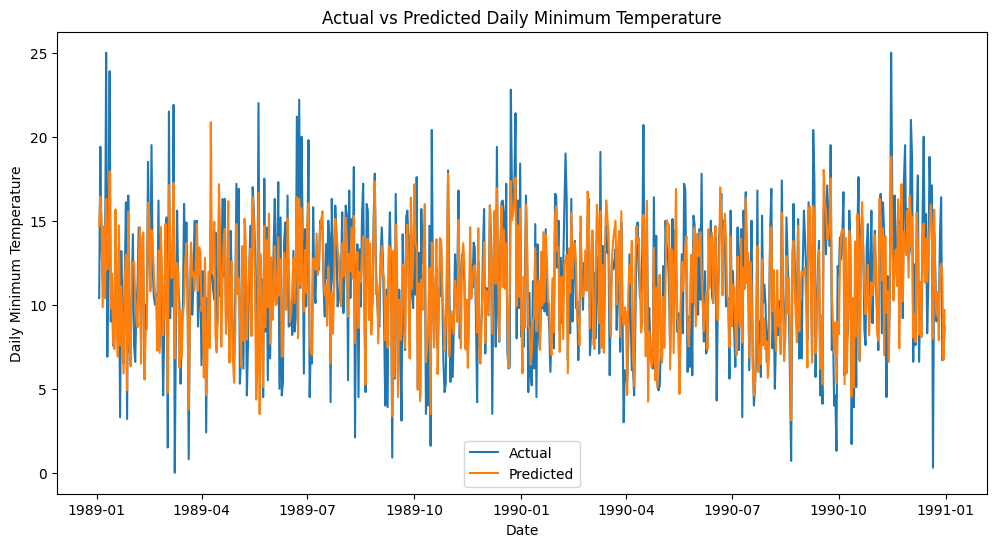

In [46]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'].iloc[-len(y_test):], y_test, label='Actual')

plt.plot(df['Date'].iloc[-len(y_test):], y_pred, label='Predicted')

plt.xlabel('Date')
plt.ylabel('Daily Minimum Temperature')
plt.title('Actual vs Predicted Daily Minimum Temperature')
plt.legend()
plt.show()


In [37]:
df['temp_last_day'] = df['Daily_min_temp'].shift(1)
df['temp_two_days_ago'] = df['Daily_min_temp'].shift(2)

In [39]:
train_size = int(0.7 * len(df))
val_size = int(0.15 * len(df))

train = df[:train_size]
val = df[train_size:train_size + val_size]
test = df[train_size + val_size:]


In [40]:
X_train, y_train = train[['temp_last_day', 'temp_two_days_ago']], train['Daily_min_temp']
X_val, y_val = val[['temp_last_day', 'temp_two_days_ago']], val['Daily_min_temp']
X_test, y_test = test[['temp_last_day', 'temp_two_days_ago']], test['Daily_min_temp']


In [50]:
from sklearn.linear_model import LinearRegression
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

prediction_value_linear_reg = linear_reg.predict(X_val)

In [51]:
df.dropna(subset=['Daily_min_temp'], inplace=True)  
from sklearn.ensemble import RandomForestRegressor
rand_forest = RandomForestRegressor(random_state=42)
rand_forest.fit(X_train, y_train)

prediction_value_random_forest = rand_forest.predict(X_val)

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Regression
mse_linear_reg = mean_squared_error(y_val, prediction_value_linear_reg)
mae_linear_reg = mean_absolute_error(y_val, prediction_value_linear_reg)
r2_linear_reg = r2_score(y_val, prediction_value_linear_reg)

# Random Forest
mse_rand_forest = mean_squared_error(y_val, prediction_value_random_forest)
mae_rand_forest = mean_absolute_error(y_val, prediction_value_random_forest)
r2_rand_forest = r2_score(y_val, prediction_value_random_forest)

print("Linear Regression -> MSE:", mse_linear_reg, "MAE:", mae_linear_reg, "R²:", r2_linear_reg)
print("Random Forest -> MSE:", mse_rand_forest, "MAE:", mae_rand_forest, "R²:", r2_rand_forest)

Linear Regression -> MSE: 6.076818989693403 MAE: 1.9323650998183235 R²: 0.621036970216016
Random Forest -> MSE: 7.765018609998037 MAE: 2.19792747560798 R²: 0.5157573421612902


In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 200],'max_depth': [3, 5, 10]}

grid = GridSearchCV(RandomForestRegressor(random_state=42),param_grid,cv=3,scoring='neg_mean_squared_error')

grid.fit(X_train, y_train)

best_rand_forest = grid.best_estimator_
val_pred_best_rand_forest = best_rand_forest.predict(X_val)
y_test_pred = best_rand_forest.predict(X_test) 



In [54]:
test_pred = best_rand_forest.predict(X_test)

print("Test MSE:", mean_squared_error(y_test, test_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))
print("Test R²:", r2_score(y_test, test_pred))


Test MSE: 5.752341605735777
Test MAE: 1.9041279141291532
Test R²: 0.6215100206651756


In [55]:
importances = best_rand_forest.feature_importances_
features = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': features,'Importance': importances}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

             Feature  Importance
0      temp_last_day    0.953885
1  temp_two_days_ago    0.046115


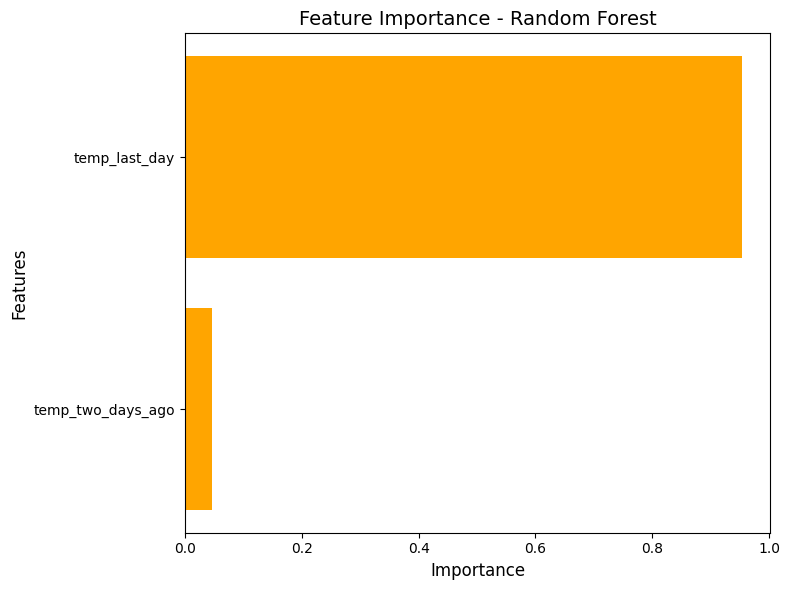

In [56]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='orange')
plt.title('Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()


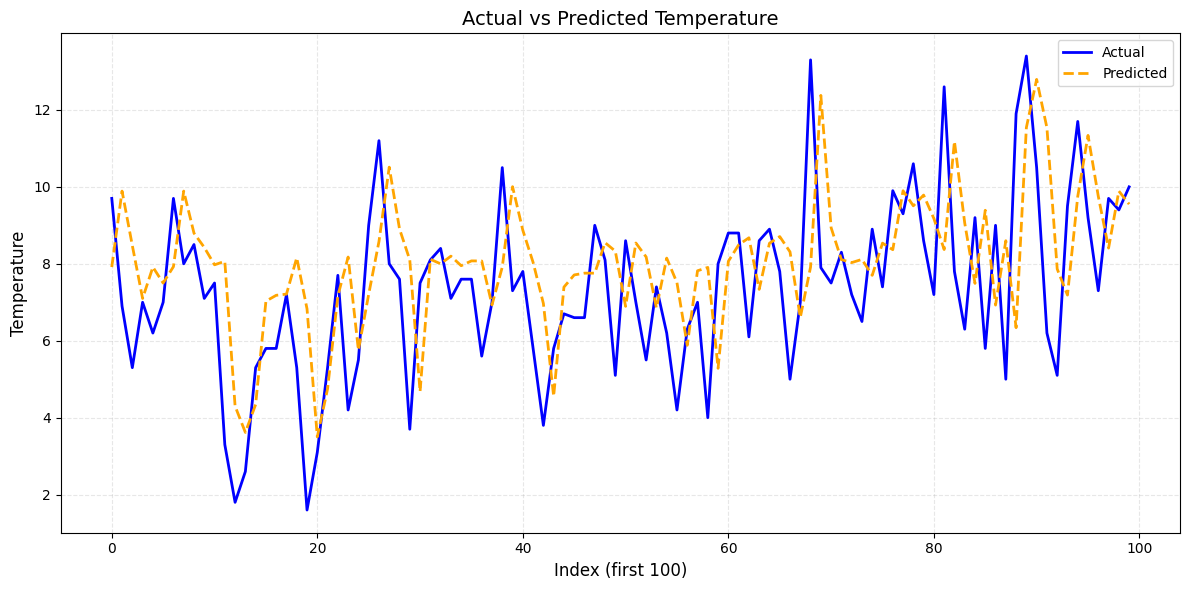

In [60]:
plt.figure(figsize=(12,6))
plt.plot(x[:100], actual[:100], color='blue', linewidth=2, label='Actual')
plt.plot(x[:100], predicted[:100], color='orange', linewidth=2, linestyle='--', label='Predicted')

plt.xlabel('Index (first 100)', fontsize=12)
plt.ylabel('Temperature', fontsize=12)
plt.title('Actual vs Predicted Temperature', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
